## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras import Sequential, layers, callbacks

## Tâche 1 : Chargement et Exploration

In [2]:
# Charger MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"\nPixel range: [{X_train.min()}, {X_train.max()}]")

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)

Pixel range: [0, 255]


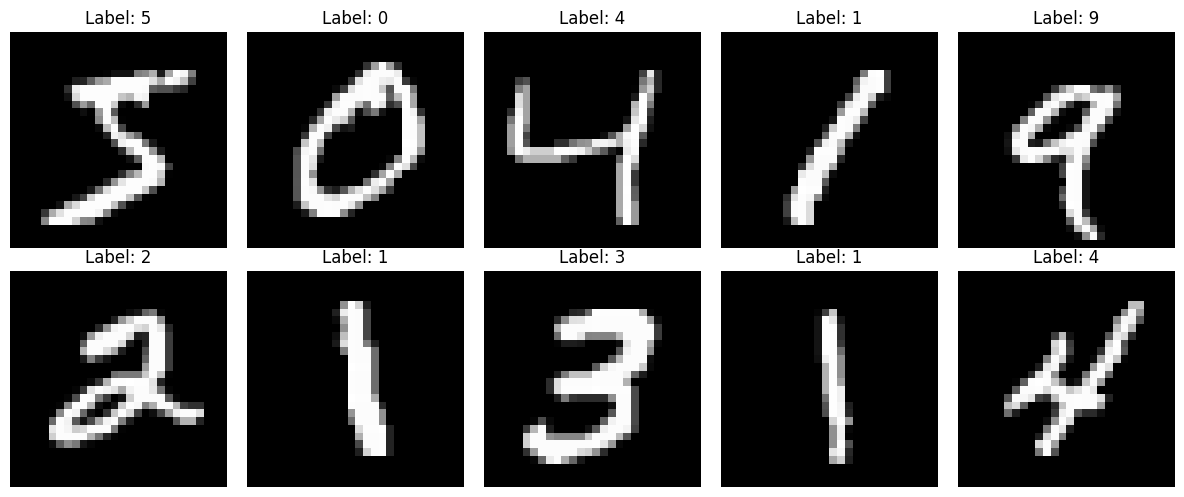

In [3]:
# Visualiser 10 images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

Distribution des classes (train):
  Classe 0: 5923 images (9.9%)
  Classe 1: 6742 images (11.2%)
  Classe 2: 5958 images (9.9%)
  Classe 3: 6131 images (10.2%)
  Classe 4: 5842 images (9.7%)
  Classe 5: 5421 images (9.0%)
  Classe 6: 5918 images (9.9%)
  Classe 7: 6265 images (10.4%)
  Classe 8: 5851 images (9.8%)
  Classe 9: 5949 images (9.9%)


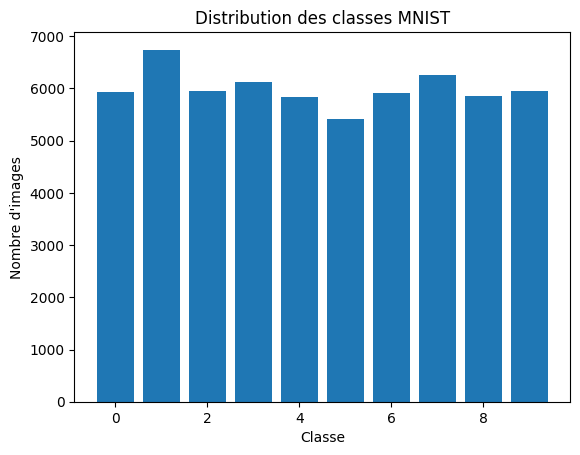

In [4]:
# Distribution des classes
unique, counts = np.unique(y_train, return_counts=True)
print("Distribution des classes (train):")
for label, count in zip(unique, counts):
    print(f"  Classe {label}: {count} images ({count/len(y_train)*100:.1f}%)")

plt.bar(unique, counts)
plt.xlabel('Classe')
plt.ylabel('Nombre d\'images')
plt.title('Distribution des classes MNIST')
plt.show()

## Tâche 2 : Préparation des Données

In [5]:
# Normaliser les pixels dans [0, 1]
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# Aplatir les images 28x28 en vecteurs 784D
X_train_flat = X_train_norm.reshape(-1, 784)
X_test_flat = X_test_norm.reshape(-1, 784)

# One-hot encoding des labels
y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)

print(f"X_train_flat shape: {X_train_flat.shape}")
print(f"X_test_flat shape: {X_test_flat.shape}")
print(f"y_train_onehot shape: {y_train_onehot.shape}")
print(f"Pixel range after normalization: [{X_train_flat.min():.2f}, {X_train_flat.max():.2f}]")

X_train_flat shape: (60000, 784)
X_test_flat shape: (10000, 784)
y_train_onehot shape: (60000, 10)
Pixel range after normalization: [0.00, 1.00]


## Tâche 3 : Architecture MLP

In [6]:
# Construire le modèle MLP
model = Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compiler
model.compile(
    optimizer="adam",
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Afficher le résumé
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

## Tâche 4 : Entraînement

In [ ]:
# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Entraîner
history = model.fit(
    X_train_flat, y_train_onehot,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8870 - loss: 0.3907 - val_accuracy: 0.9508 - val_loss: 0.1752
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9579 - loss: 0.1468 - val_accuracy: 0.9633 - val_loss: 0.1281
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9687 - loss: 0.1056 - val_accuracy: 0.9648 - val_loss: 0.1165
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9755 - loss: 0.0815 - val_accuracy: 0.9682 - val_loss: 0.1039
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9798 - loss: 0.0664 - val_accuracy: 0.9690 - val_loss: 0.1050
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9834 - loss: 0.0531 - val_accuracy: 0.9709 - val_loss: 0.0998
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9866 - loss: 0.0416 - val_accuracy: 0.9739 - val_loss: 0.0970
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9900 - loss: 0.0332 - val_accuracy: 0.

## Tâche 5 : Évaluation sur le Test Set

In [8]:
# Évaluer
test_loss, test_accuracy = model.evaluate(X_test_flat, y_test_onehot)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - accuracy: 0.9741 - loss: 0.0903
Test Loss: 0.0903
Test Accuracy: 0.9741


In [9]:
# Prédictions sur les 10 premières images
predictions = model.predict(X_test_flat[:10])
pred_classes = np.argmax(predictions, axis=1)

print("Prédictions vs Labels réels:")
for i in range(10):
    print(f"  Image {i}: Prédiction={pred_classes[i]}, Label réel={y_test[i]}, Correct={pred_classes[i]==y_test[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Prédictions vs Labels réels:
  Image 0: Prédiction=7, Label réel=7, Correct=True
  Image 1: Prédiction=2, Label réel=2, Correct=True
  Image 2: Prédiction=1, Label réel=1, Correct=True
  Image 3: Prédiction=0, Label réel=0, Correct=True
  Image 4: Prédiction=4, Label réel=4, Correct=True
  Image 5: Prédiction=1, Label réel=1, Correct=True
  Image 6: Prédiction=4, Label réel=4, Correct=True
  Image 7: Prédiction=9, Label réel=9, Correct=True
  Image 8: Prédiction=6, Label réel=5, Correct=False
  Image 9: Prédiction=9, Label réel=9, Correct=True


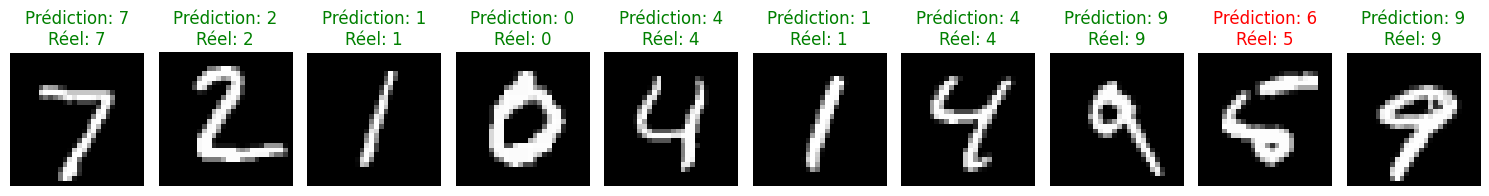

In [17]:
# Visualiser 5 exemples
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_test[i], cmap='gray')
    pred = pred_classes[i]
    true = y_test[i]
    color = 'green' if pred == true else 'red'
    ax.set_title(f'Prédiction: {pred}\nRéel: {true}', color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Tâche 6 : Analyse des Courbes d'Apprentissage

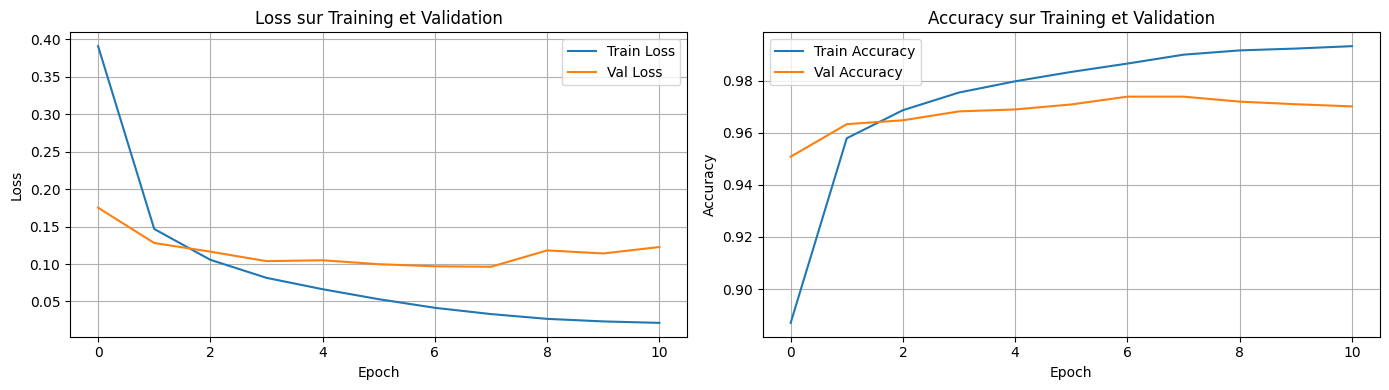

In [11]:
# Courbes de loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Loss
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss sur Training et Validation')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(history.history['accuracy'], label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy sur Training et Validation')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [12]:
# Analyse de l'overfitting
train_loss_final = history.history['loss'][-1]
val_loss_final = history.history['val_loss'][-1]
overfitting_gap = val_loss_final - train_loss_final

print(f"Train Loss Final: {train_loss_final:.4f}")
print(f"Val Loss Final: {val_loss_final:.4f}")
print(f"Overfitting Gap: {overfitting_gap:.4f}")

if overfitting_gap < 0.05:
    print("Peu d'overfitting détecté")
elif overfitting_gap < 0.15:
    print("Overfitting modéré")
else:
    print("Overfitting significatif")

Train Loss Final: 0.0215
Val Loss Final: 0.1227
Overfitting Gap: 0.1012
Overfitting modéré


## Tâche 7 : Amélioration avec Régularisation

In [ ]:
# Modèle avec régularisation
model_reg = Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu', kernel_regularizer='l2'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu', kernel_regularizer='l2'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu', kernel_regularizer='l2'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model_reg.compile(
    optimizer="adam",
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_reg.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Entraîner le modèle régularisé
history_reg = model_reg.fit(
    X_train_flat, y_train_onehot,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7138 - loss: 1.9014 - val_accuracy: 0.9076 - val_loss: 0.8526
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8494 - loss: 0.9777 - val_accuracy: 0.9198 - val_loss: 0.7068
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8706 - loss: 0.8539 - val_accuracy: 0.9319 - val_loss: 0.6294


In [15]:
# Comparaison des modèles
test_loss_orig, test_acc_orig = model.evaluate(X_test_flat, y_test_onehot, verbose=0)
test_loss_reg, test_acc_reg = model_reg.evaluate(X_test_flat, y_test_onehot, verbose=0)

print(f"Modèle Original:")
print(f"  Test Accuracy: {test_acc_orig:.4f}")
print(f"  Test Loss: {test_loss_orig:.4f}")
print(f"\nModèle avec Régularisation:")
print(f"  Test Accuracy: {test_acc_reg:.4f}")
print(f"  Test Loss: {test_loss_reg:.4f}")
print(f"\nGain de régularisation:")
print(f"  Accuracy change: {(test_acc_reg - test_acc_orig)*100:+.2f}%")

Modèle Original:
  Test Accuracy: 0.9741
  Test Loss: 0.0903

Modèle avec Régularisation:
  Test Accuracy: 0.9051
  Test Loss: 0.8575

Gain de régularisation:
  Accuracy change: -6.90%


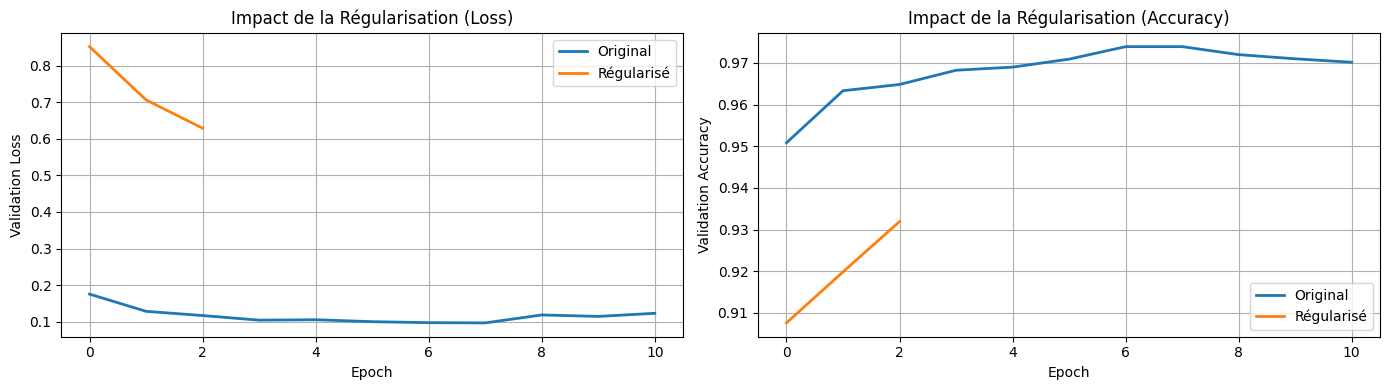

In [16]:
# Visualiser l'impact de la régularisation
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Comparaison Val Loss
axes[0].plot(history.history['val_loss'], label='Original', linewidth=2)
axes[0].plot(history_reg.history['val_loss'], label='Régularisé', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Impact de la Régularisation (Loss)')
axes[0].legend()
axes[0].grid(True)

# Comparaison Val Accuracy
axes[1].plot(history.history['val_accuracy'], label='Original', linewidth=2)
axes[1].plot(history_reg.history['val_accuracy'], label='Régularisé', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Impact de la Régularisation (Accuracy)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()